In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql://robot-startml-ro:pheiph0hahj1Vaif@"
    "postgres.lab.karpov.courses:6432/startml"
)


In [8]:
feed = pd.read_sql(
    """
    SELECT user_id, post_id, timestamp, target
    FROM public.feed_data
    WHERE action = 'view'
    LIMIT 1000000 
    """,
    con=engine
)

In [9]:
users = pd.read_sql(
    """
    SELECT user_id, age, gender, country, os, source, exp_group
    FROM public.user_data
    """,
    con=engine
)

In [10]:
posts = pd.read_sql(
    """
    SELECT post_id, topic, text
    FROM public.post_text_df
    """,
    con=engine
)

In [11]:
feed.to_csv('feed.csv', index=False)
users.to_csv('users.csv', index=False)
posts.to_csv('posts.csv', index=False)

In [12]:
posts['text_len'] = posts['text'].str.len()
posts['words_count'] = posts['text'].str.split().apply(len)
posts['unique_words_count'] = posts['text'].str.split().apply(lambda x: len(set(x)))


In [13]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

/Users/irinaazarova/Documents/курсы/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
text_model = SentenceTransformer(model_name)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9708.59it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
post_embeddings = text_model.encode(
    posts["text"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

post_embeddings.shape

Batches: 100%|██████████| 55/55 [00:17<00:00,  3.07it/s]


(7023, 384)

In [16]:
pca = PCA(n_components=32, random_state=42)
post_emb_pca = pca.fit_transform(post_embeddings)

emb_cols = [f"emb_{i}" for i in range(post_emb_pca.shape[1])]
emb_df = pd.DataFrame(post_emb_pca, columns=emb_cols)

In [17]:
posts = posts.loc[:, ~posts.columns.str.startswith("emb_")]

In [18]:
posts = pd.concat(
    [posts.reset_index(drop=True), emb_df.reset_index(drop=True)],
    axis=1
)

In [20]:
split_time = feed['timestamp'].quantile(0.8)

feed_train = feed[feed['timestamp'] < split_time].copy()
feed_test = feed[feed['timestamp'] >= split_time].copy()

In [21]:
feed_train_with_emb = feed_train.merge(
    posts[["post_id"] + emb_cols],
    on="post_id",
    how="left"
)

In [22]:
user_view_emb = (
    feed_train_with_emb
    .groupby("user_id")[emb_cols]
    .mean()
    .reset_index()
)

user_view_emb = user_view_emb.rename(
    columns={col: f"user_view_{col}" for col in emb_cols}
)

In [23]:
user_like_emb = (
    feed_train_with_emb[feed_train_with_emb["target"] == 1]
    .groupby("user_id")[emb_cols]
    .mean()
    .reset_index()
)

user_like_emb = user_like_emb.rename(
    columns={col: f"user_like_{col}" for col in emb_cols}
)

In [24]:
train = feed_train.merge(users, on="user_id", how="left").merge(posts, on="post_id", how="left")
test = feed_test.merge(users, on="user_id", how="left").merge(posts, on="post_id", how="left")

In [25]:
train = train.merge(user_view_emb, on="user_id", how="left")
test = test.merge(user_view_emb, on="user_id", how="left")

train = train.merge(user_like_emb, on="user_id", how="left")
test = test.merge(user_like_emb, on="user_id", how="left")

In [26]:
def add_similarity_features(df, emb_cols):
    df = df.copy()
    post_matrix = df[emb_cols].values

    user_view_cols = [f"user_view_{col}" for col in emb_cols]
    user_like_cols = [f"user_like_{col}" for col in emb_cols]

    user_view_matrix = df[user_view_cols].fillna(0).values
    user_like_matrix = df[user_like_cols].fillna(0).values

    df["sim_view_dot"] = np.sum(post_matrix * user_view_matrix, axis=1)
    df["sim_like_dot"] = np.sum(post_matrix * user_like_matrix, axis=1)

    post_norm = np.linalg.norm(post_matrix, axis=1) + 1e-8
    user_view_norm = np.linalg.norm(user_view_matrix, axis=1) + 1e-8
    user_like_norm = np.linalg.norm(user_like_matrix, axis=1) + 1e-8

    df["sim_view_cos"] = df["sim_view_dot"] / (post_norm * user_view_norm)
    df["sim_like_cos"] = df["sim_like_dot"] / (post_norm * user_like_norm)

    return df

In [27]:
train = add_similarity_features(train, emb_cols)
test = add_similarity_features(test, emb_cols)

In [28]:
user_stats = feed_train.groupby("user_id").agg(
    user_views=("post_id", "count"), 
    user_likes=("target", "sum"),
    user_like_rate=("target", "mean") 
).reset_index()

train = train.merge(user_stats, on="user_id", how="left")
test = test.merge(user_stats, on="user_id", how="left")


In [29]:
post_stats = feed_train.groupby("post_id").agg( 
    post_views=("user_id", "count"),
    post_likes=("target", "sum"),
    post_like_rate=("target", "mean")
).reset_index()

train = train.merge(post_stats, on="post_id", how="left")
test = test.merge(post_stats, on="post_id", how="left")

In [30]:
posts = posts.merge(post_stats, on="post_id", how="left")

posts["post_views"] = posts["post_views"].fillna(0)
posts["post_likes"] = posts["post_likes"].fillna(0)
posts["post_like_rate"] = posts["post_like_rate"].fillna(0)

In [31]:
tmp = feed_train.merge(
    posts[["post_id", "topic"]],
    on="post_id",
    how="left"
)

user_topic = tmp.groupby(["user_id", "topic"]).agg(
    user_topic_views=("post_id", "count"),
    user_topic_likes=("target", "sum"),
    user_topic_like_rate=("target", "mean")
).reset_index()

train = train.merge(user_topic, on=["user_id", "topic"], how="left")
test = test.merge(user_topic, on=["user_id", "topic"], how="left")


In [32]:
train = train.drop(columns=["text"])
test = test.drop(columns=["text"])

In [33]:
DROP_COLS = ['user_id', 'post_id', 'timestamp', 'target']

MODEL_FEATURES = [
    col for col in train.columns
    if col not in [
        "target",
        "post_id",
        "user_id",
        "timestamp"
    ]
    
    and not col.startswith("emb_")
    and not col.startswith("user_view_")
    and not col.startswith("user_like_")
]

for col in ["sim_view_cos", "sim_like_cos"]:
    if col not in MODEL_FEATURES:
        MODEL_FEATURES.append(col)

X_train = train[MODEL_FEATURES].copy()
X_test = test[MODEL_FEATURES].copy()

y_train = train['target']
y_test = test['target']

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

num_cols = [col for col in num_cols if col in X_train.columns]
cat_cols = [col for col in cat_cols if col in X_train.columns]

X_train.loc[:, cat_cols] = X_train[cat_cols].fillna('unknown')
X_test.loc[:, cat_cols] = X_test[cat_cols].fillna('unknown')

X_train.loc[:, num_cols] = X_train[num_cols].fillna(0)
X_test.loc[:, num_cols] = X_test[num_cols].fillna(0)

print(len(num_cols), len(X_train.columns))
print(set(num_cols) - set(X_train.columns))

for col in ["sim_view_cos", "sim_like_cos"]:
    print(col, col in X_train.columns)

18 22
set()
sim_view_cos True
sim_like_cos True


In [34]:
train

,user_id,post_id,timestamp,target,age,gender,country,os,source,exp_group,...,sim_like_cos,user_views,user_likes,user_like_rate,post_views,post_likes,post_like_rate,user_topic_views,user_topic_likes,user_topic_like_rate
0,160212,5103,2021-11-27 14:54:31,0,19,1,Russia,Android,organic,3,...,0.003687,183,26,0.142077,79,9,0.113924,81,8,0.098765
1,160212,4723,2021-11-27 14:56:46,0,19,1,Russia,Android,organic,3,...,-0.379072,183,26,0.142077,79,5,0.063291,81,8,0.098765
2,160212,5318,2021-11-27 14:58:06,0,19,1,Russia,Android,organic,3,...,-0.186492,183,26,0.142077,86,7,0.081395,81,8,0.098765
3,160212,5038,2021-11-27 14:59:44,0,19,1,Russia,Android,organic,3,...,-0.488044,183,26,0.142077,88,4,0.045455,81,8,0.098765
4,160212,7055,2021-11-27 15:00:17,0,19,1,Russia,Android,organic,3,...,0.013229,183,26,0.142077,71,10,0.140845,81,8,0.098765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799993,153811,3550,2021-11-05 21:38:13,0,17,0,Russia,Android,organic,3,...,-0.293691,167,19,0.113772,90,3,0.033333,29,2,0.068966
799994,153811,4661,2021-11-05 21:40:05,0,17,0,Russia,Android,organic,3,...,0.056874,167,19,0.113772,78,9,0.115385,70,6,0.085714
799995,153811,6743,2021-11-05 21:43:01,0,17,0,Russia,Android,organic,3,...,0.118146,167,19,0.113772,82,8,0.097561,70,6,0.085714
799996,153811,2268,2021-11-05 21:45:04,0,17,0,Russia,Android,organic,3,...,0.081031,167,19,0.113772,114,11,0.096491,8,1,0.125000


In [35]:
train.columns.duplicated().sum()

np.int64(0)

In [36]:
test

,user_id,post_id,timestamp,target,age,gender,country,os,source,exp_group,...,sim_like_cos,user_views,user_likes,user_like_rate,post_views,post_likes,post_like_rate,user_topic_views,user_topic_likes,user_topic_like_rate
0,50180,4774,2021-12-13 08:20:50,0,16,1,Russia,Android,ads,4,...,-0.065498,73,13,0.178082,193,32,0.165803,25.0,3.0,0.120000
1,50180,2376,2021-12-13 08:21:52,1,16,1,Russia,Android,ads,4,...,0.013987,73,13,0.178082,202,37,0.183168,19.0,4.0,0.210526
2,50180,1805,2021-12-13 08:24:31,1,16,1,Russia,Android,ads,4,...,0.584290,73,13,0.178082,262,32,0.122137,13.0,6.0,0.461538
3,50180,1651,2021-12-13 08:27:05,0,16,1,Russia,Android,ads,4,...,0.753537,73,13,0.178082,259,25,0.096525,13.0,6.0,0.461538
4,50180,2999,2021-12-13 08:28:14,0,16,1,Russia,Android,ads,4,...,0.160425,73,13,0.178082,211,31,0.146919,19.0,4.0,0.210526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199997,63052,2723,2021-12-19 17:12:06,1,27,1,Russia,Android,ads,3,...,-0.240999,288,27,0.093750,185,23,0.124324,74.0,7.0,0.094595
199998,63052,1443,2021-12-19 17:13:54,0,27,1,Russia,Android,ads,3,...,0.099642,288,27,0.093750,254,30,0.118110,25.0,2.0,0.080000
199999,63052,2905,2021-12-19 17:16:00,1,27,1,Russia,Android,ads,3,...,-0.049200,288,27,0.093750,178,28,0.157303,74.0,7.0,0.094595
200000,63052,2799,2021-12-19 17:17:38,0,27,1,Russia,Android,ads,3,...,-0.025751,288,27,0.093750,261,28,0.107280,74.0,7.0,0.094595


In [37]:
train.to_csv('train.csv', index=False)

In [38]:
test.to_csv('test.csv', index=False)

In [39]:
df = pd.concat([train, test], axis=0, ignore_index=True)

In [40]:
df.to_csv('df.csv', index=False)

In [41]:
"""
df.to_sql(
   "irina_azarova_features_lesson_22",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50_000,
    method="multi"
)
"""

'\ndf.to_sql(\n   "irina_azarova_features_lesson_22",\n    con=engine,\n    if_exists="replace",\n    index=False,\n    chunksize=50_000,\n    method="multi"\n)\n'

In [42]:
from catboost import CatBoostClassifier


In [43]:
model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

In [44]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.5988249	best: 0.5988249 (0)	total: 269ms	remaining: 3m 8s


100:	test: 0.6383824	best: 0.6383824 (100)	total: 13.5s	remaining: 1m 20s
200:	test: 0.6406347	best: 0.6407382 (192)	total: 24.3s	remaining: 1m
300:	test: 0.6413666	best: 0.6414945 (237)	total: 35.5s	remaining: 47s
400:	test: 0.6420289	best: 0.6420289 (400)	total: 46.5s	remaining: 34.7s
500:	test: 0.6423270	best: 0.6423514 (498)	total: 57.5s	remaining: 22.8s
600:	test: 0.6424264	best: 0.6424752 (589)	total: 1m 8s	remaining: 11.3s
699:	test: 0.6423480	best: 0.6425055 (620)	total: 1m 19s	remaining: 0us

bestTest = 0.6425054899
bestIteration = 620

Shrink model to first 621 iterations.


In [45]:
from sklearn.metrics import roc_auc_score

proba = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, proba)

np.float64(0.6425054898995247)

In [46]:
test["score"] = model.predict_proba(X_test)[:, 1]


In [47]:
def hitrate_at_k(df, k=5):
    hits = []

    for user_id, group in df.groupby("user_id"): 
        top_k = group.sort_values("score", ascending=False).head(k)
        hit = int(top_k["target"].max() == 1)
        hits.append(hit)

    return sum(hits) / len(hits)

In [48]:
hr5 = hitrate_at_k(test, k=5)
print(f"HitRate@5 = {hr5:.4f}")

HitRate@5 = 0.6403


In [49]:
feed_full_with_emb = feed.merge(
    posts[["post_id"] + emb_cols],
    on="post_id",
    how="left"
)

user_view_emb_full = (
    feed_full_with_emb
    .groupby("user_id")[emb_cols]
    .mean()
    .reset_index()
)
user_view_emb_full = user_view_emb_full.rename(
    columns={col: f"user_view_{col}" for col in emb_cols}
)

user_like_emb_full = (
    feed_full_with_emb[feed_full_with_emb["target"] == 1]
    .groupby("user_id")[emb_cols]
    .mean()
    .reset_index()
)
user_like_emb_full = user_like_emb_full.rename(
    columns={col: f"user_like_{col}" for col in emb_cols}
)

In [50]:
model.save_model("model_test.cbm", format="cbm")


In [51]:
import os
from catboost import CatBoostClassifier


def get_model_path(path: str) -> str:
    if os.environ.get("IS_LMS") == "1":
        MODEL_PATH = "/workdir/user_input/model"
    else:
        MODEL_PATH = path
    return MODEL_PATH


def load_models():
    model_path = get_model_path("model_test.cbm")

    model = CatBoostClassifier()
    model.load_model(model_path)

    return model

In [52]:
loaded_model = load_models()
loaded_model.predict_proba(X_test[:10])


array([[0.86528256, 0.13471744],
       [0.86186242, 0.13813758],
       [0.53461837, 0.46538163],
       [0.33427263, 0.66572737],
       [0.73235946, 0.26764054],
       [0.98896412, 0.01103588],
       [0.89111714, 0.10888286],
       [0.18453172, 0.81546828],
       [0.91372139, 0.08627861],
       [0.88066989, 0.11933011]])

In [53]:
import features

df = features.load_features()


In [54]:
df.head()

,user_id,age,gender,country,os,source,exp_group,user_views,user_likes,user_like_rate
0,200,34,1,Russia,Android,ads,3,0.0,0.0,0.0
1,201,37,0,Russia,Android,ads,0,0.0,0.0,0.0
2,202,17,1,Russia,Android,ads,4,0.0,0.0,0.0
3,203,18,0,Russia,iOS,ads,1,0.0,0.0,0.0
4,204,36,0,Russia,Android,ads,3,0.0,0.0,0.0


In [55]:
user_stats_full = feed.groupby("user_id").agg(
    user_views=("post_id", "count"),
    user_likes=("target", "sum"),
    user_like_rate=("target", "mean"),
).reset_index()

In [56]:
user_features = users.merge(
    user_stats_full,
    on="user_id",
    how="left"
)

user_features = user_features.merge(user_view_emb_full, on="user_id", how="left")
user_features = user_features.merge(user_like_emb_full, on="user_id", how="left")

In [57]:
cat_cols = user_features.select_dtypes(include=["object"]).columns
num_cols = user_features.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

user_features[cat_cols] = user_features[cat_cols].fillna("unknown")
user_features[num_cols] = user_features[num_cols].fillna(0)

In [58]:

print(posts.columns[posts.columns.duplicated()])

import numpy as np
print(np.isinf(posts.select_dtypes(include=np.number)).sum().sum())

print(posts.select_dtypes(include="object").columns)

posts = posts.copy()

Index([], dtype='object')
0
Index(['topic', 'text'], dtype='object')


In [59]:
posts.to_sql(
    "irina_azarova_posts_features_lesson_24",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50000,
    method="multi"
)

7023

In [60]:
tmp_full = feed.merge(
    posts[["post_id", "topic"]],
    on="post_id",
    how="left"
)

user_topic_full = tmp_full.groupby(["user_id", "topic"]).agg(
    user_topic_views=("post_id", "count"),
    user_topic_likes=("target", "sum"),
    user_topic_like_rate=("target", "mean")
).reset_index()

user_topic_full.to_sql(
    "irina_azarova_user_topic_features_lesson_24",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50000,
    method="multi"
)

16677

In [61]:
print(len(user_features))
print(users["user_id"].nunique())
print(user_features["user_id"].nunique())

163205
163205
163205


In [62]:
print(user_features["user_id"].nunique())
print(users["user_id"].nunique())
print(10 in user_features["user_id"].values)

163205
163205
False


In [63]:
user_features.to_sql(
    "irina_azarova_features_lesson_24_users",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50000,
    method="multi"
)

163205

In [65]:
import matplotlib.pyplot as plt

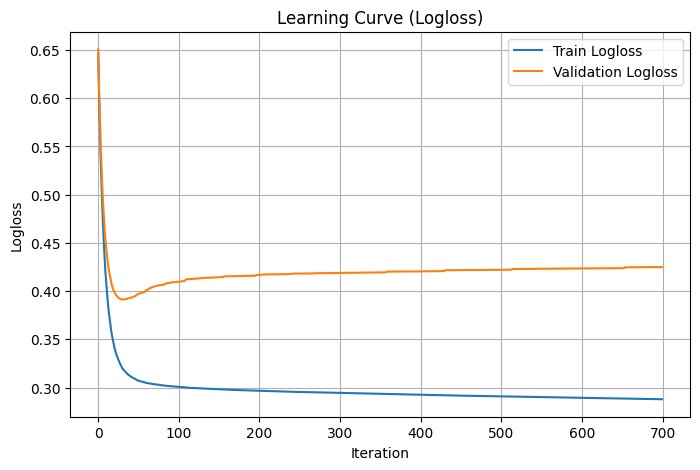

In [66]:
results = model.get_evals_result()

train_logloss = results['learn']['Logloss']
test_logloss = results['validation']['Logloss']

plt.figure(figsize=(8,5))
plt.plot(train_logloss, label='Train Logloss')
plt.plot(test_logloss, label='Validation Logloss')

plt.xlabel('Iteration')
plt.ylabel('Logloss')
plt.title('Learning Curve (Logloss)')
plt.legend()
plt.grid(True)
plt.show()

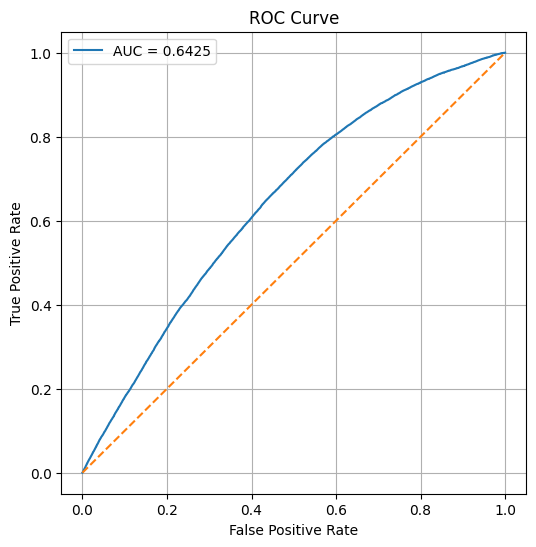

In [67]:
from sklearn.metrics import roc_curve, auc

probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

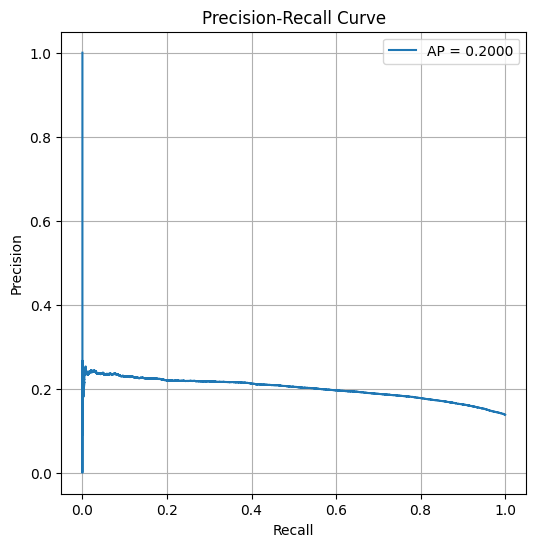

In [68]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, probs)
ap_score = average_precision_score(y_test, probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f'AP = {ap_score:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

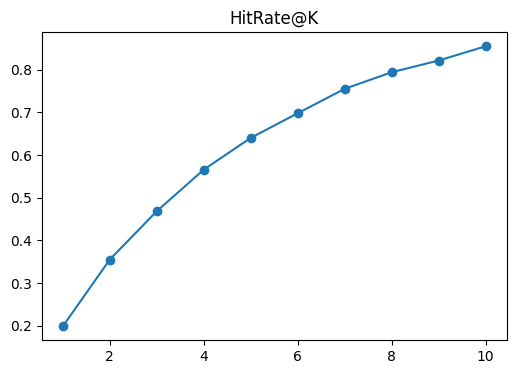

In [69]:
ks = list(range(1, 11))
scores = [hitrate_at_k(test, k) for k in ks]

plt.figure(figsize=(6,4))
plt.plot(ks, scores, marker='o')
plt.title("HitRate@K")
plt.show()

In [71]:
import seaborn as sns

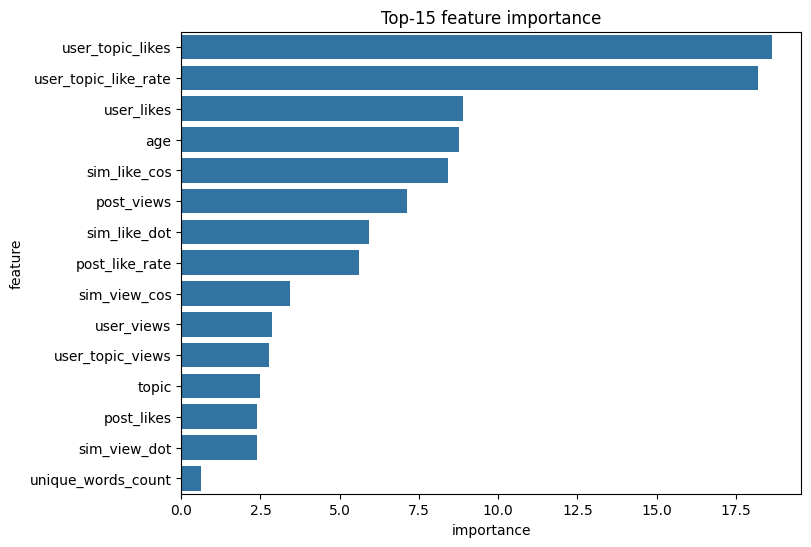

In [72]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': model.feature_names_,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title("Top-15 feature importance")
plt.show()